In [15]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from pathlib import Path

## load my data

In [16]:
data_path = Path("/Users/zhengtaosun/Documents/bootcamp_Zhengtao_Sun/homework/stage9_hw/data/processed/S&P500_stock_hist_5y.parquet")
df = pd.read_parquet(data_path)
df = df[df['ticker'].isin(['NVDA'])]
df = df.reset_index(drop=True)
df.head()

Price,date,adj close,close,high,low,open,volume,ticker,daily_rtn,excess_return
0,2020-08-20,12.101113,12.14100,12.37500,11.87875,11.97500,921388000,NVDA,0.000206,-0.002953
1,2020-08-21,12.641834,12.68350,12.80875,12.19525,12.20175,999868000,NVDA,0.044684,0.041242
2,2020-08-24,12.678459,12.72025,12.91250,12.50750,12.88375,490564000,NVDA,0.002897,-0.007147
3,2020-08-25,12.708115,12.75000,12.76125,12.57375,12.63075,289076000,NVDA,0.002339,-0.001257
4,2020-08-26,12.731039,12.77300,12.86850,12.67775,12.79925,321244000,NVDA,0.001804,-0.008392


## Feature Engineering 

In [17]:
df["mom_5"] = (df["adj close"]/df["adj close"].shift(5)-1).shift(1)
df["log_return"] = np.log(df["adj close"]).diff().shift(1)
df["vol_std_5"] = df["log_return"].rolling(5).std().shift(1)
df['next_excess_return'] = df['excess_return'].shift(-1) 
df = df.copy().dropna()
df.head()

Price,date,adj close,close,high,low,open,volume,ticker,daily_rtn,excess_return,mom_5,log_return,vol_std_5,next_excess_return
7,2020-08-31,13.330562,13.3745,13.57500,13.03775,13.18275,500840000,NVDA,0.017246,0.019441,0.036602,0.040314,0.020906,0.026168
8,2020-09-01,13.779715,13.8210,13.99375,13.43650,13.48000,511316000,NVDA,0.033693,0.026168,0.051434,0.017099,0.019453,0.022656
9,2020-09-02,14.303645,14.3465,14.72675,13.90000,14.70375,874012000,NVDA,0.038022,0.022656,0.084324,0.033138,0.019705,-0.057649
10,2020-09-03,12.976623,13.0155,13.88450,12.87875,13.82875,945128000,NVDA,-0.092775,-0.057649,0.123525,0.037317,0.021437,-0.022062
11,2020-09-04,12.584794,12.6225,13.17500,11.70475,12.78375,1463684000,NVDA,-0.030195,-0.022062,0.030974,-0.097365,0.021361,-0.028453


## Split

In [18]:
cut=int(len(df)*0.8)
train, test = df.iloc[:cut], df.iloc[cut:]
features=['vol_std_5','mom_5',"log_return"]  # extend as you add features
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['next_excess_return'], test['next_excess_return']

## Pipeline + Model

In [19]:
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
rmse = mean_squared_error(y_te_reg, pred)
print('RMSE:', rmse)

RMSE: 0.0006502504273204746


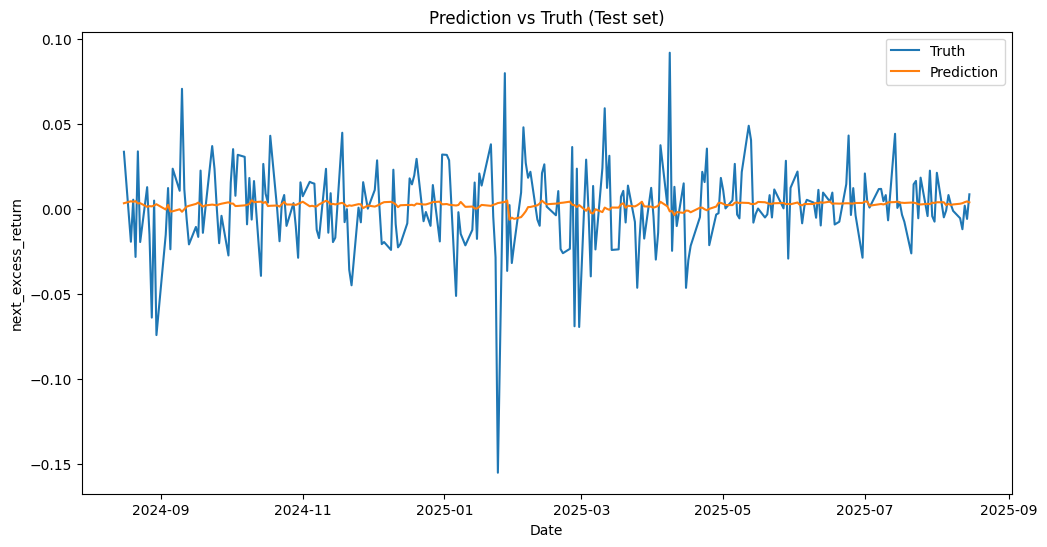

In [20]:
test_plot = test.copy()
test_plot['y_true'] = y_te_reg.values
test_plot['y_pred'] = pred

plt.figure(figsize=(12,6))
plt.plot(test_plot['date'], test_plot['y_true'], label='Truth')
plt.plot(test_plot['date'], test_plot['y_pred'], label='Prediction')
plt.title('Prediction vs Truth (Test set)')
plt.xlabel('Date'); plt.ylabel('next_excess_return')
plt.legend()
plt.show()

## Interpretation
- Shift feature to the previous day and return to the next day make sure prevent using future data and leakage. 
- The data are influeced by the outliers and features we chose might lack of linear correlation with output.
- Need to more relevant features and might need to apply more advanced models. 